# Import libraries

In [ ]:
import os
import json
import logging
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional, List
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import zipfile
import shutil

# Configuration

In [ ]:
output_directory = "./cleaned"
binarized_zip_filename = "binarized_posters_only.zip"

input_directory = "./input_images"
output_directory = "./cleaned"
os.makedirs(input_directory, exist_ok=True)

## Image formatting pipeline

In [ ]:
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger(__name__)

def display_image(image_path, title="Image"):
    img = cv2.imread(image_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.title(title)
        plt.axis('off')
        plt.show()

In [ ]:
@dataclass
class PipelineConfig:

    # Target long-edge resolution for the model
    target_long_edge: int = 1344

    # Deskew
    deskew_enabled: bool = True
    deskew_max_angle: float = 5.0

    # Denoising
    denoise_enabled: bool = True
    denoise_strength: int = 10
    denoise_template_window: int = 7
    denoise_search_window: int = 21

    # Adaptive binarization
    binarize_enabled: bool = True
    binarize_block_size: int = 51
    binarize_c: int = 15

    # CLAHE contrast enhancement
    clahe_enabled: bool = True
    clahe_clip_limit: float = 3.0
    clahe_tile_grid: tuple = (8, 8)

    # Border cleanup — remove N% of each edge
    border_crop_enabled: bool = True
    border_crop_pct: float = 0.02

    # Multi-scale tiling: split tall posters into overlapping horizontal strips
    tiling_enabled: bool = True
    tile_overlap_pct: float = 0.15
    num_tiles: int = 3

    # Which output variants to produce
    output_grayscale: bool = True
    output_binarized: bool = True
    output_enhanced: bool = True
    output_tiles: bool = True
    output_original_resized: bool = True

In [ ]:
def load_image(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    log.info(f"Loaded {path}  shape={img.shape}")
    return img

def resize_to_target(img: np.ndarray, target_long_edge: int) -> np.ndarray:
    h, w = img.shape[:2]
    long_edge = max(h, w)
    if long_edge <= target_long_edge:
        return img
    scale = target_long_edge / long_edge
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    log.info(f"Resized {w}x{h} → {new_w}x{new_h}")
    return resized

def to_grayscale(img: np.ndarray) -> np.ndarray:
    if len(img.shape) == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def deskew(gray: np.ndarray, max_angle: float = 5.0) -> np.ndarray:
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(
        edges, 1, np.pi / 180, threshold=100,
        minLineLength=gray.shape[1] // 4, maxLineGap=10
    )
    if lines is None:
        return gray

    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if abs(angle) < max_angle:
            angles.append(angle)

    if not angles:
        return gray

    median_angle = np.median(angles)
    if abs(median_angle) < 0.1:
        return gray

    log.info(f"Deskew: correcting {median_angle:.2f}°")
    h, w = gray.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, median_angle, 1.0)
    rotated = cv2.warpAffine(
        gray, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )
    return rotated

def denoise(gray: np.ndarray, cfg: PipelineConfig) -> np.ndarray:
    denoised = cv2.fastNlMeansDenoising(
        gray,
        h=cfg.denoise_strength,
        templateWindowSize=cfg.denoise_template_window,
        searchWindowSize=cfg.denoise_search_window,
    )
    log.info("Denoised (Non-local means)")
    return denoised

def adaptive_binarize(gray: np.ndarray, cfg: PipelineConfig) -> np.ndarray:
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        cfg.binarize_block_size,
        cfg.binarize_c,
    )
    log.info("Adaptive binarization applied")
    return binary

def enhance_clahe(gray: np.ndarray, cfg: PipelineConfig) -> np.ndarray:
    clahe = cv2.createCLAHE(
        clipLimit=cfg.clahe_clip_limit,
        tileGridSize=cfg.clahe_tile_grid,
    )
    enhanced = clahe.apply(gray)
    log.info("CLAHE contrast enhancement applied")
    return enhanced

def crop_borders(img: np.ndarray, pct: float) -> np.ndarray:
    h, w = img.shape[:2]
    dy, dx = int(h * pct), int(w * pct)
    cropped = img[dy : h - dy, dx : w - dx]
    log.info(f"Border crop: removed {pct*100:.0f}% margins → {cropped.shape[1]}x{cropped.shape[0]}")
    return cropped

def generate_tiles(img: np.ndarray, num_tiles: int, overlap_pct: float) -> List[np.ndarray]:
    h, w = img.shape[:2]
    if num_tiles <= 1:
        return [img]

    overlap_px = int(h * overlap_pct / num_tiles)
    stride = (h - overlap_px) // num_tiles
    tiles = []
    for i in range(num_tiles):
        y_start = max(0, i * stride - (overlap_px // 2 if i > 0 else 0))
        y_end = min(h, y_start + stride + overlap_px)
        tile = img[y_start:y_end, :]
        tiles.append(tile)
        log.info(f"Tile {i+1}/{num_tiles}: rows {y_start}–{y_end}  ({tile.shape[0]}x{tile.shape[1]})")

    return tiles

In [ ]:
def process_single_image(input_path: str, output_dir: str, cfg: PipelineConfig) -> dict:
    stem = Path(input_path).stem
    os.makedirs(output_dir, exist_ok=True)

    manifest = {"source": input_path, "outputs": {}}

    bgr = load_image(input_path)
    bgr = resize_to_target(bgr, cfg.target_long_edge)

    if cfg.output_original_resized:
        p = os.path.join(output_dir, f"{stem}_resized.jpg")
        cv2.imwrite(p, bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        manifest["outputs"]["resized_colour"] = p

    gray = to_grayscale(bgr)

    if cfg.border_crop_enabled:
        gray = crop_borders(gray, cfg.border_crop_pct)
        bgr = crop_borders(bgr, cfg.border_crop_pct)

    if cfg.deskew_enabled:
        gray = deskew(gray, cfg.deskew_max_angle)

    if cfg.denoise_enabled:
        gray = denoise(gray, cfg)

    if cfg.output_grayscale:
        p = os.path.join(output_dir, f"{stem}_grayscale.jpg")
        cv2.imwrite(p, gray, [cv2.IMWRITE_JPEG_QUALITY, 95])
        manifest["outputs"]["grayscale"] = p

    if cfg.clahe_enabled:
        enhanced = enhance_clahe(gray, cfg)
        if cfg.output_enhanced:
            p = os.path.join(output_dir, f"{stem}_enhanced.jpg")
            cv2.imwrite(p, enhanced, [cv2.IMWRITE_JPEG_QUALITY, 95])
            manifest["outputs"]["enhanced"] = p
    else:
        enhanced = gray

    if cfg.binarize_enabled:
        binary = adaptive_binarize(gray, cfg)
        if cfg.output_binarized:
            p = os.path.join(output_dir, f"{stem}_binarized.png")
            cv2.imwrite(p, binary)
            manifest["outputs"]["binarized"] = p
    else:
        binary = gray

    if cfg.tiling_enabled and cfg.output_tiles:
        tiles = generate_tiles(enhanced, cfg.num_tiles, cfg.tile_overlap_pct)
        tile_paths = []
        for i, tile in enumerate(tiles):
            p = os.path.join(output_dir, f"{stem}_tile_{i+1}.jpg")
            cv2.imwrite(p, tile, [cv2.IMWRITE_JPEG_QUALITY, 95])
            tile_paths.append(p)
        manifest["outputs"]["tiles"] = tile_paths

    manifest_path = os.path.join(output_dir, f"{stem}_manifest.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)

    log.info(f"✓ Done — outputs in {output_dir}")
    return manifest

In [ ]:
os.makedirs(output_directory, exist_ok=True)

# Upload ZIP file
print("Please upload 'images.zip' (or any zip containing your posters)...")
uploaded = files.upload()

zip_filename = None
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        zip_filename = filename
        break

if zip_filename:
    # Extract the ZIP file
    print(f"\nExtracting {zip_filename}...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(input_directory)

    # Find all images in the extracted folder
    valid_exts = {".jpg", ".jpeg", ".png", ".tiff", ".tif", ".bmp", ".webp"}
    image_paths = []
    for root, dirs, file_list in os.walk(input_directory):
        for file in file_list:
            if Path(file).suffix.lower() in valid_exts:
                if not file.startswith("._"):
                    image_paths.append(os.path.join(root, file))

    print(f"Found {len(image_paths)} images to process.\n")

    # 3. Setup configuration
    cfg = PipelineConfig(
        target_long_edge=1344,
        num_tiles=3,
        denoise_strength=10,
        binarize_block_size=51,
        binarize_c=15,
        clahe_clip_limit=3.0,
        deskew_enabled=True,
        denoise_enabled=True,
        binarize_enabled=True,
        tiling_enabled=True
    )

    # Process all images in a batch
    all_manifests = []
    for img_path in image_paths:
        print(f"Processing: {Path(img_path).name}")
        try:
            manifest = process_single_image(img_path, output_directory, cfg)
            all_manifests.append(manifest)
        except Exception as e:
            print(f"  -> Failed to process {Path(img_path).name}: {e}")

    print(f"\nBatch processing complete! Successfully processed {len(all_manifests)} images.")

else:
    print("No ZIP file was found in the upload.")

Please upload 'images.zip' (or any zip containing your posters)...


Saving image.zip to image (1).zip

Extracting image (1).zip...
Found 30 images to process.

Processing: NFA178R12-10.jpg
Processing: NFA178R12-38.jpg
Processing: NFA178R12-30.jpg
Processing: NFA178R12-259.jpg
Processing: NFA178R12-43.jpg
Processing: NFA178R12-211.jpg
Processing: NFA178R12-35.jpg
Processing: NFA178R12-18.jpg
Processing: NFA178R12-28.jpg
Processing: NFA178R12-17.jpg
Processing: NFA178R12-215.jpg
Processing: NFA178R12-207.jpg
Processing: NFA178R12-205.jpg
Processing: NFA178R12-263.jpg
Processing: NFA178R12-103.jpg
Processing: NFA178R12-16.jpg
Processing: NFA178R12-41.jpg
Processing: NFA178R12-104.jpg
Processing: NFA178R12-40.jpg
Processing: NFA178R12-258.jpg
Processing: NFA178R12-37.jpg
Processing: NFA178R12-262.jpg
Processing: NFA178R12-9.jpg
Processing: NFA178R12-204.jpg
Processing: NFA178R12-220.jpg
Processing: NFA178R12-267.jpg
Processing: NFA178R12-209.jpg
Processing: NFA178R12-26.jpg
Processing: NFA178R12-39.jpg
Processing: NFA178R12-208.jpg

Batch processing comple

--- PREVIEW OF FIRST IMAGE ---


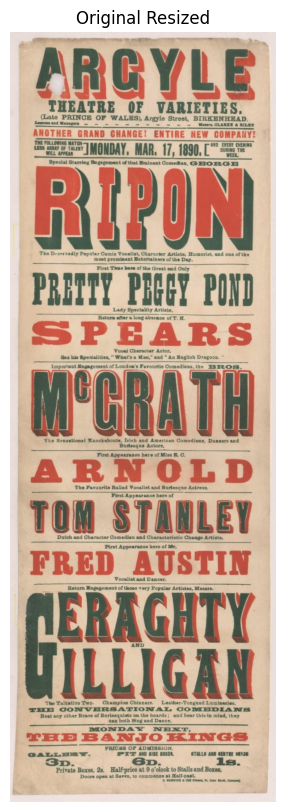

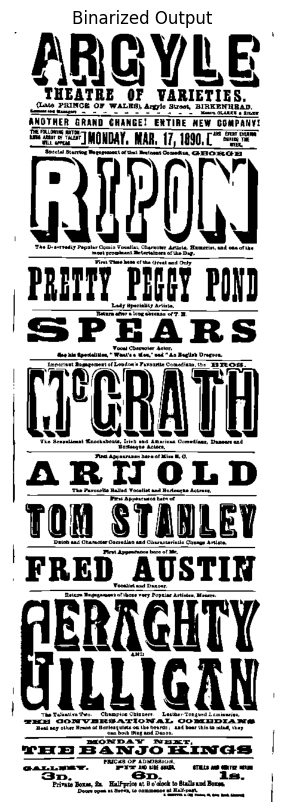


Zipping cleaned images for download...
Ready! You can now download 'cleaned_posters.zip' from the file browser on the left.


In [ ]:
if 'all_manifests' in locals() and len(all_manifests) > 0:
    # Show a preview of the FIRST processed image
    print("--- PREVIEW OF FIRST IMAGE ---")
    first_manifest = all_manifests[0]
    outputs = first_manifest.get("outputs", {})

    if "resized_colour" in outputs:
        display_image(outputs["resized_colour"], "Original Resized")
    if "binarized" in outputs:
        display_image(outputs["binarized"], "Binarized Output")

    # Zip the outputs for easy downloading
    print("\nZipping cleaned images for download...")
    shutil.make_archive("cleaned_posters", 'zip', output_directory)
    print("Ready! You can now download 'cleaned_posters.zip' from the file browser on the left.")
else:
    print("No processed images to display or zip.")

In [ ]:
print(f"Searching for binarized images in '{output_directory}'...")

# Create a new ZIP file
binarized_count = 0
with zipfile.ZipFile(binarized_zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, file_list in os.walk(output_directory):
        for file in file_list:
            # Check if the file is a binarized output
            if file.endswith("_binarized.png"):
                file_path = os.path.join(root, file)
                zipf.write(file_path, arcname=file)
                binarized_count += 1

# Provide feedback and download
if binarized_count > 0:
    print(f"Successfully zipped {binarized_count} binarized images!")
    print(f"Downloading '{binarized_zip_filename}'...")
    files.download(binarized_zip_filename)
else:
    print("No binarized images were found. Did the pipeline finish running?")

Searching for binarized images in './cleaned'...
Successfully zipped 30 binarized images!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>